# Transfer Learning-Based Ensemble of CNNs and Vision Transformers
# for Melanoma Diagnosis and Image Retrieval

**Complete Replication of:**  
*Sarıateş, M.; Özbay, E. Transfer Learning-Based Ensemble of CNNs and Vision Transformers for Accurate Melanoma Diagnosis and Image Retrieval. Diagnostics 2025, 15, 1928.*

---

## Dataset Paths:
```
/kaggle/input/melanoma-cancer-dataset/train/Benign
/kaggle/input/melanoma-cancer-dataset/train/Malignant
/kaggle/input/melanoma-cancer-dataset/test/Benign
/kaggle/input/melanoma-cancer-dataset/test/Malignant
```

## Implementation Overview:
1. **Transfer Learning Models**: DenseNet121, InceptionV3, ViT, Xception
2. **Ensemble Learning**: Weighted averaging with Random Search optimization
3. **CBIR System**: Individual + Multi-model feature-level fusion
4. **Evaluation**: Accuracy, Precision, Recall, F1, AUC, mAP, PR curves
5. **Statistical Analysis**: Bootstrap 95% confidence intervals (n=100)

---

In [1]:
# ============================================================================
# SECTION 1: IMPORTS AND SETUP
# ============================================================================

!pip install -q tensorflow keras scikit-learn matplotlib seaborn pandas numpy pillow tqdm

import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import DenseNet121, InceptionV3, Xception
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adamax, Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(gpus)} available")

# Paths
BASE_PATH = '/kaggle/input/melanoma-cancer-dataset'
TRAIN_PATH = f'{BASE_PATH}/train'
TEST_PATH = f'{BASE_PATH}/test'

# Hyperparameters (from paper)
BATCH_SIZE = 32
EPOCHS = 40
LR = 0.001
FINE_TUNE_LR = 0.0001
IMG_224 = (224, 224)
IMG_299 = (299, 299)
CLASS_NAMES = ['Benign', 'Malignant']

# Create directories
for d in ['models', 'results', 'features']:
    os.makedirs(d, exist_ok=True)

print("\n✓ Setup complete!")

2026-02-07 09:04:39.754915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770455079.943848      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770455079.999830      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770455080.473988      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770455080.474041      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770455080.474044      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: 1 available

✓ Setup complete!


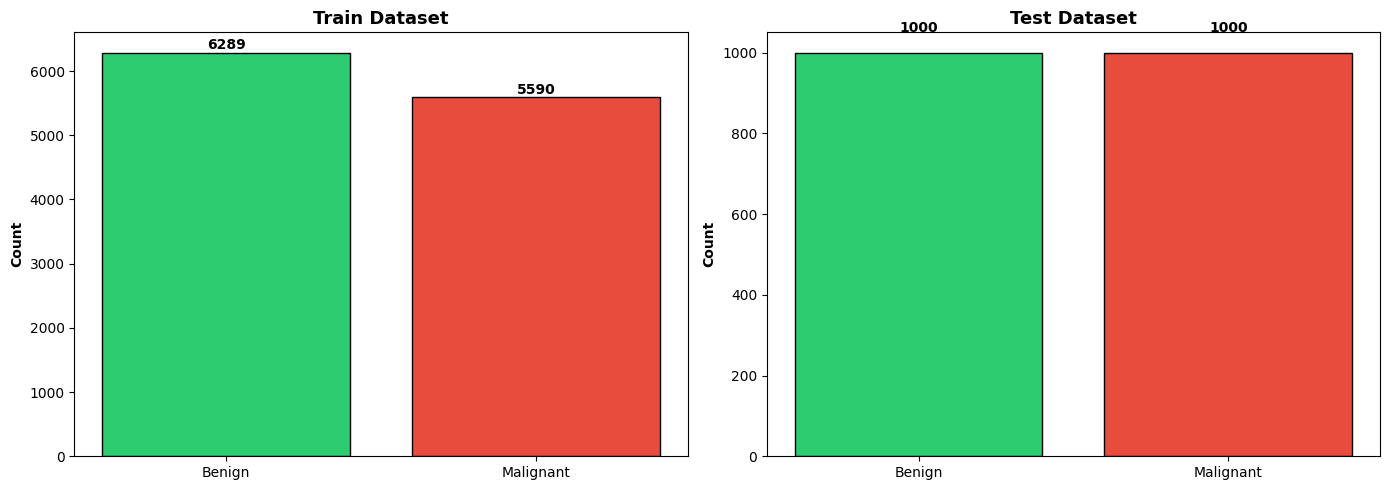

Train: 11879 | Test: 2000


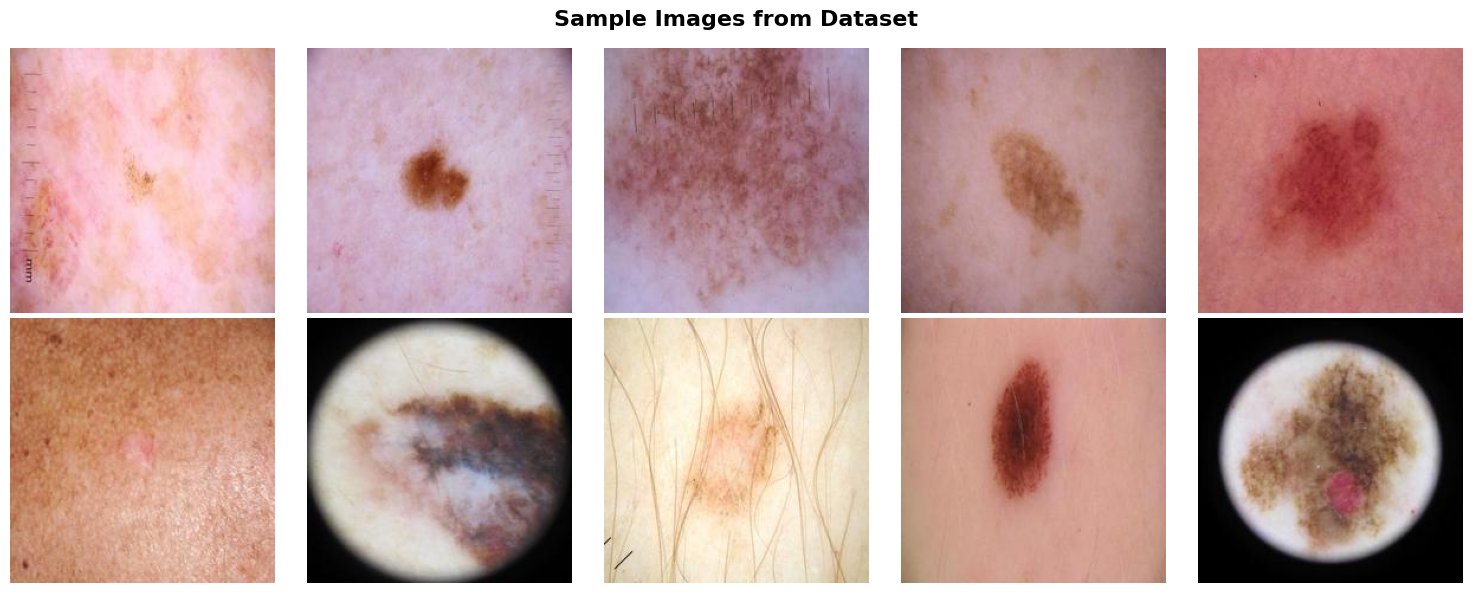


✓ Visualizations 1-2 complete!


In [2]:
# ============================================================================
# SECTION 2-3: DATA LOADING AND VISUALIZATION
# Visualization 1: Dataset distribution
# Visualization 2: Sample images
# ============================================================================

def count_images(path):
    counts = {}
    for split in ['train', 'test']:
        counts[split] = {c: len(glob(f"{path}/{split}/{c}/*")) for c in CLASS_NAMES}
    return counts

img_counts = count_images(BASE_PATH)

# VIZ 1: Dataset distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, split in enumerate(['train', 'test']):
    counts = list(img_counts[split].values())
    ax[i].bar(CLASS_NAMES, counts, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax[i].set_title(f'{split.title()} Dataset', fontweight='bold', fontsize=13)
    ax[i].set_ylabel('Count', fontweight='bold')
    for j, v in enumerate(counts):
        ax[i].text(j, v+50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/01_dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Train: {sum(img_counts['train'].values())} | Test: {sum(img_counts['test'].values())}")

# VIZ 2: Sample images
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(CLASS_NAMES):
    imgs = glob(f"{TRAIN_PATH}/{cls}/*")[:5]
    for j, img_path in enumerate(imgs):
        img = load_img(img_path, target_size=IMG_224)
        ax[i, j].imshow(img)
        ax[i, j].axis('off')
        if j == 0:
            ax[i, j].set_ylabel(cls, fontsize=14, fontweight='bold')
plt.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/02_sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations 1-2 complete!")

In [3]:
# ============================================================================
# SECTION 4: DATA GENERATORS
# ============================================================================

# Augmentation (from paper specifications)
train_aug = ImageDataGenerator(
    rescale=1./255, rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.2, zoom_range=0.1,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.8, 1.2], validation_split=0.2
)
test_aug = ImageDataGenerator(rescale=1./255)

# 224x224 generators (DenseNet121, ViT)
train_224 = train_aug.flow_from_directory(TRAIN_PATH, target_size=IMG_224, batch_size=BATCH_SIZE,
                                          class_mode='binary', subset='training', shuffle=True, seed=SEED)
val_224 = train_aug.flow_from_directory(TRAIN_PATH, target_size=IMG_224, batch_size=BATCH_SIZE,
                                        class_mode='binary', subset='validation', shuffle=False, seed=SEED)
test_224 = test_aug.flow_from_directory(TEST_PATH, target_size=IMG_224, batch_size=BATCH_SIZE,
                                        class_mode='binary', shuffle=False)

# 299x299 generators (InceptionV3, Xception)
train_299 = train_aug.flow_from_directory(TRAIN_PATH, target_size=IMG_299, batch_size=BATCH_SIZE,
                                          class_mode='binary', subset='training', shuffle=True, seed=SEED)
val_299 = train_aug.flow_from_directory(TRAIN_PATH, target_size=IMG_299, batch_size=BATCH_SIZE,
                                        class_mode='binary', subset='validation', shuffle=False, seed=SEED)
test_299 = test_aug.flow_from_directory(TEST_PATH, target_size=IMG_299, batch_size=BATCH_SIZE,
                                        class_mode='binary', shuffle=False)

print(f"Train: {train_224.samples} | Val: {val_224.samples} | Test: {test_224.samples}")
print("✓ Data generators ready!")

Found 9504 images belonging to 2 classes.
Found 2375 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 9504 images belonging to 2 classes.
Found 2375 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Train: 9504 | Val: 2375 | Test: 2000
✓ Data generators ready!


In [4]:
# ============================================================================
# SECTION 5: VISION TRANSFORMER (ViT) IMPLEMENTATION
# ============================================================================

@tf.keras.utils.register_keras_serializable()
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
    def call(self, images):
        patches = tf.image.extract_patches(images, [1, self.patch_size, self.patch_size, 1],
                                          [1, self.patch_size, self.patch_size, 1], [1,1,1,1], "VALID")
        return tf.reshape(patches, [tf.shape(images)[0], -1, patches.shape[-1]])
    def get_config(self):
        return {**super().get_config(), "patch_size": self.patch_size}

@tf.keras.utils.register_keras_serializable()
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches, self.projection_dim = num_patches, projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(num_patches, projection_dim)
    def call(self, patch):
        return self.projection(patch) + self.position_embedding(tf.range(self.num_patches))
    def get_config(self):
        return {**super().get_config(), "num_patches": self.num_patches, "projection_dim": self.projection_dim}

def create_vit(img_size=224, patch_size=16, proj_dim=64, n_layers=8, n_heads=4, mlp_units=[2048, 1024]):
    inputs = layers.Input((img_size, img_size, 3))
    encoded = PatchEncoder((img_size//patch_size)**2, proj_dim)(Patches(patch_size)(inputs))
    
    for _ in range(n_layers):
        x = layers.LayerNormalization(epsilon=1e-6)(encoded)
        x = layers.MultiHeadAttention(n_heads, proj_dim, dropout=0.1)(x, x)
        x = layers.Add()([x, encoded])
        y = layers.LayerNormalization(epsilon=1e-6)(x)
        y = layers.Dense(proj_dim*2, activation=tf.nn.gelu)(y)
        y = layers.Dropout(0.1)(y)
        y = layers.Dense(proj_dim, activation=tf.nn.gelu)(y)
        encoded = layers.Add()([layers.Dropout(0.1)(y), x])
    
    x = layers.LayerNormalization(epsilon=1e-6)(encoded)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    for units in mlp_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs)

print("✓ ViT architecture defined!")

✓ ViT architecture defined!


In [5]:
# ============================================================================
# SECTION 6-7: MODEL BUILDERS & TRAINING FUNCTIONS
# ============================================================================

def build_densenet121():
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(*IMG_224, 3))
    for l in base.layers[:121]: l.trainable = False
    return models.Sequential([
        base,
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

def build_xception():
    base = Xception(weights='imagenet', include_top=False, input_shape=(*IMG_299, 3))
    for l in base.layers[:80]: l.trainable = False
    return models.Sequential([
        base,
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

def build_inceptionv3():
    base = InceptionV3(weights='imagenet', include_top=False, input_shape=(*IMG_299, 3))
    for l in base.layers: l.trainable = False
    return models.Sequential([
        base,
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

def train_model(model, train_gen, val_gen, name, epochs=EPOCHS, lr=LR):
    opt = Adam(lr) if 'ViT' in name else Adamax(lr)
    model.compile(opt, 'binary_crossentropy', metrics=['accuracy'])
    
    callbacks = [
        ModelCheckpoint(f'models/{name}_best.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ]
    
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    hist = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks, verbose=1)
    return model, hist

def evaluate_model(model, test_gen, name):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    y_true = test_gen.classes
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{'='*60}\n{name} Results:\n{'='*60}")
    print(f"Accuracy:  {acc*100:.2f}% | Precision: {prec*100:.2f}%")
    print(f"Recall:    {rec*100:.2f}% | F1-Score:  {f1*100:.2f}% | AUC: {roc_auc:.4f}\n{'='*60}\n")
    
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1,
            'auc': roc_auc, 'confusion_matrix': cm, 'y_true': y_true, 'y_pred': y_pred,
            'y_pred_proba': y_prob, 'fpr': fpr, 'tpr': tpr}

print("✓ Model builders and training functions ready!")

✓ Model builders and training functions ready!


In [6]:
# ============================================================================
# SECTION 8-12: TRAIN ALL MODELS
# ============================================================================

# Train DenseNet121
model_d, hist_d = train_model(build_densenet121(), train_224, val_224, 'DenseNet121')
res_d = evaluate_model(model_d, test_224, 'DenseNet121')
model_d.save('models/DenseNet121_final.h5')

# Train Xception
model_x, hist_x = train_model(build_xception(), train_299, val_299, 'Xception')
res_x = evaluate_model(model_x, test_299, 'Xception')
model_x.save('models/Xception_final.h5')

# Train ViT
model_v = create_vit()
model_v, hist_v = train_model(model_v, train_224, val_224, 'ViT')
res_v = evaluate_model(model_v, test_224, 'ViT')
model_v.save('models/ViT_final.h5')

# Train InceptionV3 (initial)
model_i, hist_i = train_model(build_inceptionv3(), train_299, val_299, 'InceptionV3')
res_i_init = evaluate_model(model_i, test_299, 'InceptionV3_Initial')

# Fine-tune InceptionV3 (unfreeze layers 150+)
print("\nFine-tuning InceptionV3...")
base_i = model_i.layers[0]
for l in base_i.layers[:150]: l.trainable = False
for l in base_i.layers[150:]: l.trainable = True

model_i.compile(Adamax(FINE_TUNE_LR), 'binary_crossentropy', metrics=['accuracy'])
hist_i_ft = model_i.fit(train_299, validation_data=val_299, epochs=20,
                        callbacks=[
                            ModelCheckpoint('models/InceptionV3_finetuned.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
                            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
                            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1)
                        ], verbose=1)

res_i = evaluate_model(model_i, test_299, 'InceptionV3')
model_i.save('models/InceptionV3_final.h5')
print(f"Improvement: +{(res_i['accuracy'] - res_i_init['accuracy'])*100:.2f}%")

all_results = [res_d, res_i, res_v, res_x]
print("\n✓ All 4 models trained!")

I0000 00:00:1770455103.658035      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training DenseNet121
Epoch 1/40


I0000 00:00:1770455151.175778     170 service.cc:152] XLA service 0x7db3bc006290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770455151.175815     170 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770455158.451981     170 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/297 ━━━━━━━━━━━━━━━━━━━━ 10:12:00 124s/step - accuracy: 0.5000 - loss: 0.7401

I0000 00:00:1770455232.604823     170 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

297/297 ━━━━━━━━━━━━━━━━━━━━ 270s 909ms/step - accuracy: 0.9348 - loss: 0.1635 - val_accuracy: 0.8404 - val_loss: 0.4564 - learning_rate: 1.0000e-04
Epoch 6/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9452 - loss: 0.1474
Epoch 6: val_accuracy improved from 0.84042 to 0.84295, saving model to models/InceptionV3_finetuned.h5


297/297 ━━━━━━━━━━━━━━━━━━━━ 280s 941ms/step - accuracy: 0.9452 - loss: 0.1474 - val_accuracy: 0.8429 - val_loss: 0.4348 - learning_rate: 1.0000e-04
Epoch 7/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9443 - loss: 0.1372
Epoch 7: val_accuracy did not improve from 0.84295
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 931ms/step - accuracy: 0.9443 - loss: 0.1372 - val_accuracy: 0.8404 - val_loss: 0.4761 - learning_rate: 1.0000e-04
Epoch 8/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.9551 - loss: 0.1157
Epoch 8: val_accuracy improved from 0.84295 to 0.84337, saving model to models/InceptionV3_finetuned.h5



Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
297/297 ━━━━━━━━━━━━━━━━━━━━ 281s 947ms/step - accuracy: 0.9550 - loss: 0.1157 - val_accuracy: 0.8434 - val_loss: 0.5179 - learning_rate: 1.0000e-04
Epoch 9/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9581 - loss: 0.1087
Epoch 9: val_accuracy did not improve from 0.84337
297/297 ━━━━━━━━━━━━━━━━━━━━ 272s 914ms/step - accuracy: 0.9581 - loss: 0.1087 - val_accuracy: 0.8333 - val_loss: 0.5472 - learning_rate: 5.0000e-05
Epoch 10/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.9604 - loss: 0.0997
Epoch 10: val_accuracy did not improve from 0.84337
297/297 ━━━━━━━━━━━━━━━━━━━━ 263s 885ms/step - accuracy: 0.9604 - loss: 0.0997 - val_accuracy: 0.8429 - val_loss: 0.5317 - learning_rate: 5.0000e-05
Epoch 11/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9670 - loss: 0.0875
Epoch 11: val_accuracy did not improve from 0.84337
297/297 ━━━━━━━━━━━━━━━━━━━━ 277s 934ms/step - accuracy

297/297 ━━━━━━━━━━━━━━━━━━━━ 274s 922ms/step - accuracy: 0.9702 - loss: 0.0784 - val_accuracy: 0.8472 - val_loss: 0.5256 - learning_rate: 5.0000e-05
Epoch 13/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9694 - loss: 0.0847
Epoch 13: val_accuracy did not improve from 0.84716

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
297/297 ━━━━━━━━━━━━━━━━━━━━ 273s 919ms/step - accuracy: 0.9694 - loss: 0.0847 - val_accuracy: 0.8349 - val_loss: 0.5729 - learning_rate: 5.0000e-05
Epoch 14/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.9770 - loss: 0.0668
Epoch 14: val_accuracy did not improve from 0.84716
297/297 ━━━━━━━━━━━━━━━━━━━━ 276s 930ms/step - accuracy: 0.9770 - loss: 0.0668 - val_accuracy: 0.8341 - val_loss: 0.5526 - learning_rate: 2.5000e-05
Epoch 15/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.9729 - loss: 0.0699
Epoch 15: val_accuracy did not improve from 0.84716
297/297 ━━━━━━━━━━━━━━━━━━━━ 274s 924ms/step - accur


InceptionV3 Results:
Accuracy:  92.00% | Precision: 94.40%
Recall:    89.30% | F1-Score:  91.78% | AUC: 0.9747

Improvement: +0.15%

✓ All 4 models trained!



PERFORMANCE COMPARISON
      Model accuracy precision recall f1_score
DenseNet121   94.60%    95.88% 93.20%   94.52%
InceptionV3   92.00%    94.40% 89.30%   91.78%
        ViT   89.70%    94.11% 84.70%   89.16%
   Xception   93.15%    95.18% 90.90%   92.99%


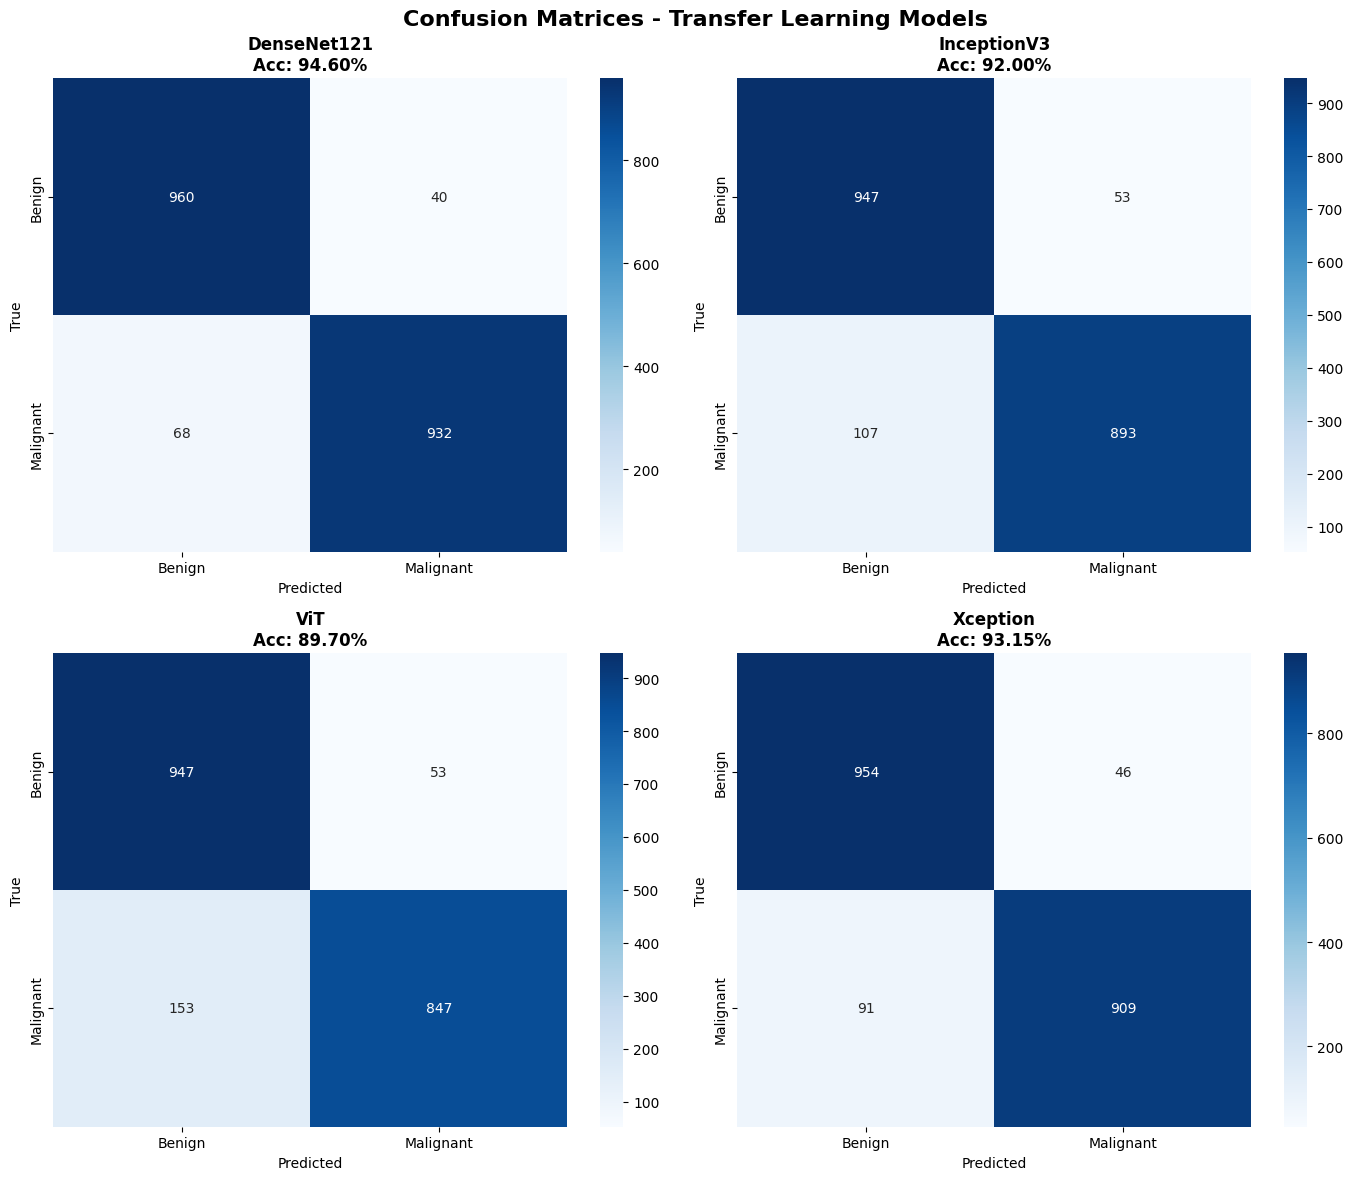

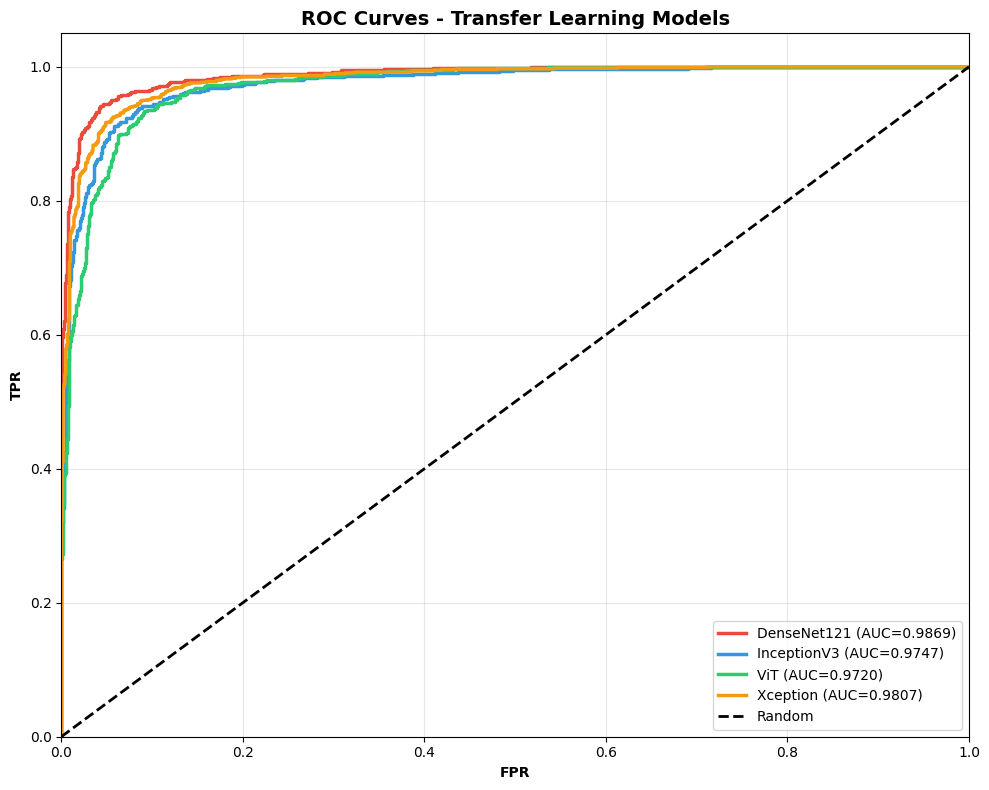

✓ Visualizations 4-6 complete!


In [7]:
# ============================================================================
# VISUALIZATION 3-6: Individual Model Results
# VIZ 3: Two-label confusion matrix (table format - shown in VIZ 5)
# VIZ 4: Performance table
# VIZ 5: Confusion matrices
# VIZ 6: ROC curves
# ============================================================================

# VIZ 4: Performance table
perf_df = pd.DataFrame([{**{'Model': r['model']}, **{k: f"{r[k]*100:.2f}%" for k in ['accuracy', 'precision', 'recall', 'f1_score']}} for r in all_results])
print("\n" + "="*80 + "\nPERFORMANCE COMPARISON\n" + "="*80)
print(perf_df.to_string(index=False))
print("="*80)
perf_df.to_csv('results/04_performance_table.csv', index=False)

# VIZ 5: Confusion matrices
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
for i, r in enumerate(all_results):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax.ravel()[i])
    ax.ravel()[i].set_title(f"{r['model']}\nAcc: {r['accuracy']*100:.2f}%", fontweight='bold')
    ax.ravel()[i].set_ylabel('True'); ax.ravel()[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices - Transfer Learning Models', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('results/05_confusion_matrices.png', dpi=300, bbox_inches='tight'); plt.show()

# VIZ 6: ROC curves
plt.figure(figsize=(10, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, r in enumerate(all_results):
    plt.plot(r['fpr'], r['tpr'], color=colors[i], lw=2.5, label=f"{r['model']} (AUC={r['auc']:.4f})")
plt.plot([0,1], [0,1], 'k--', lw=2, label='Random')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('FPR', fontweight='bold'); plt.ylabel('TPR', fontweight='bold')
plt.title('ROC Curves - Transfer Learning Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/06_roc_curves.png', dpi=300, bbox_inches='tight'); plt.show()

print("✓ Visualizations 4-6 complete!")

In [8]:
# ============================================================================
# SECTION 16: ENSEMBLE LEARNING WITH RANDOM SEARCH
# ============================================================================

def weighted_ensemble(preds_dict, weights):
    return sum(preds_dict[k] * weights[k] for k in preds_dict) / sum(weights.values())

def random_search_weights(preds_dict, y_true, n_trials=2000, patience=100):
    models = list(preds_dict.keys())
    best_w, best_auc, no_improve = None, 0, 0
    
    for trial in tqdm(range(n_trials), desc="Random Search"):
        w = {m: np.random.uniform(0, 1) for m in models}
        total = sum(w.values())
        w = {m: v/total for m, v in w.items()}
        
        ens_pred = weighted_ensemble(preds_dict, w)
        fpr, tpr, _ = roc_curve(y_true, ens_pred)
        curr_auc = auc(fpr, tpr)
        
        if curr_auc > best_auc:
            best_auc, best_w, no_improve = curr_auc, w.copy(), 0
        else:
            no_improve += 1
        
        if no_improve >= patience:
            print(f"Early stop at trial {trial+1}")
            break
    
    print(f"\nBest AUC: {best_auc:.6f}")
    for m, w in best_w.items(): print(f"  {m:20s}: {w:.6f}")
    return best_w, best_auc

# Get validation predictions
val_224.reset(); val_299.reset()
preds_val = {
    'DenseNet121': model_d.predict(val_224, verbose=0).flatten(),
    'InceptionV3': model_i.predict(val_299, verbose=0).flatten(),
    'ViT': model_v.predict(val_224, verbose=0).flatten(),
    'Xception': model_x.predict(val_299, verbose=0).flatten()
}
val_224.reset()

# Optimize weights
opt_w, best_val_auc = random_search_weights(preds_val, val_224.classes, 2000, 100)

# Get test predictions
test_224.reset(); test_299.reset()
preds_test = {
    'DenseNet121': model_d.predict(test_224, verbose=0).flatten(),
    'InceptionV3': model_i.predict(test_299, verbose=0).flatten(),
    'ViT': model_v.predict(test_224, verbose=0).flatten(),
    'Xception': model_x.predict(test_299, verbose=0).flatten()
}
test_224.reset()

# Ensemble predictions
ens_prob = weighted_ensemble(preds_test, opt_w)
ens_pred = (ens_prob > 0.5).astype(int)
y_test = test_224.classes

# Evaluate ensemble
ens_acc = accuracy_score(y_test, ens_pred)
ens_prec = precision_score(y_test, ens_pred)
ens_rec = recall_score(y_test, ens_pred)
ens_f1 = f1_score(y_test, ens_pred)
ens_cm = confusion_matrix(y_test, ens_pred)
fpr_e, tpr_e, _ = roc_curve(y_test, ens_prob)
ens_auc = auc(fpr_e, tpr_e)

res_ens = {'model': 'Ensemble', 'accuracy': ens_acc, 'precision': ens_prec, 'recall': ens_rec,
           'f1_score': ens_f1, 'auc': ens_auc, 'confusion_matrix': ens_cm,
           'y_true': y_test, 'y_pred': ens_pred, 'y_pred_proba': ens_prob,
           'fpr': fpr_e, 'tpr': tpr_e, 'weights': opt_w}

print(f"\n{'='*60}\nEnsemble Results:\n{'='*60}")
print(f"Accuracy:  {ens_acc*100:.2f}% | Precision: {ens_prec*100:.2f}%")
print(f"Recall:    {ens_rec*100:.2f}% | F1-Score:  {ens_f1*100:.2f}% | AUC: {ens_auc:.4f}\n{'='*60}\n")
print("✓ Ensemble model complete!")

Random Search:  10%|▉         | 198/2000 [00:00<00:01, 902.15it/s]


Early stop at trial 199

Best AUC: 0.952971
  DenseNet121         : 0.526368
  InceptionV3         : 0.094635
  ViT                 : 0.189980
  Xception            : 0.189017

Ensemble Results:
Accuracy:  95.30% | Precision: 96.51%
Recall:    94.00% | F1-Score:  95.24% | AUC: 0.9899

✓ Ensemble model complete!


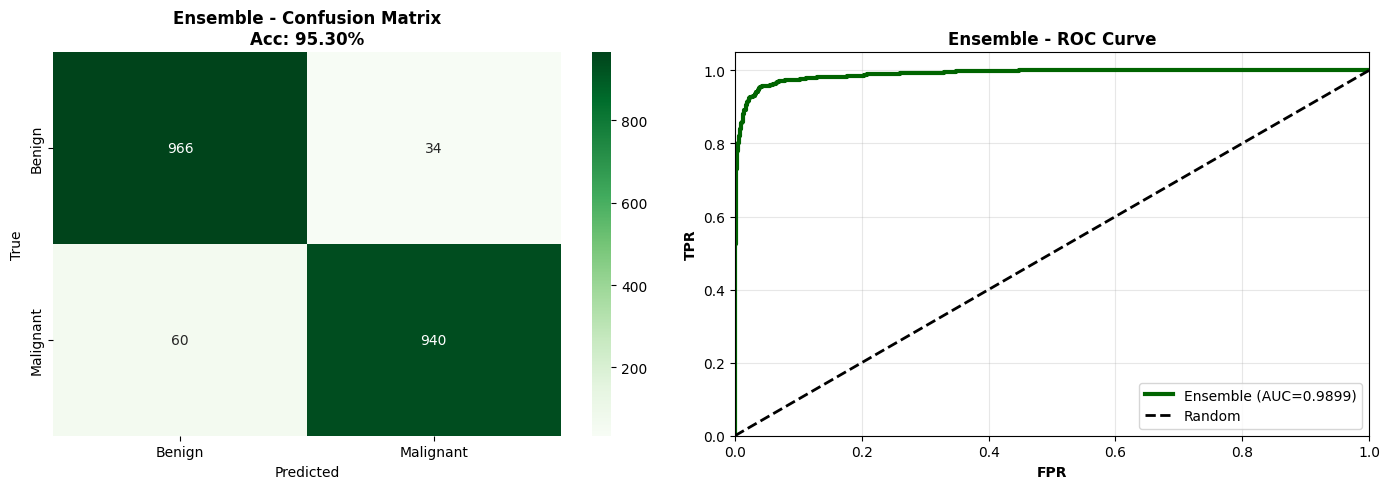


ENSEMBLE PERFORMANCE
   Model accuracy precision recall f1_score
Ensemble   95.30%    96.51% 94.00%   95.24%
✓ Visualizations 7-8 complete!


In [9]:
# ============================================================================
# VISUALIZATION 7-8: Ensemble Results
# VIZ 7: Ensemble confusion matrix
# VIZ 8: Ensemble performance table
# ============================================================================

# VIZ 7-8: Combined figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ens_cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title(f"Ensemble - Confusion Matrix\nAcc: {ens_acc*100:.2f}%", fontweight='bold')
ax[0].set_ylabel('True'); ax[0].set_xlabel('Predicted')

ax[1].plot(fpr_e, tpr_e, 'darkgreen', lw=3, label=f'Ensemble (AUC={ens_auc:.4f})')
ax[1].plot([0,1], [0,1], 'k--', lw=2, label='Random')
ax[1].set_xlim([0,1]); ax[1].set_ylim([0,1.05])
ax[1].set_xlabel('FPR', fontweight='bold'); ax[1].set_ylabel('TPR', fontweight='bold')
ax[1].set_title('Ensemble - ROC Curve', fontweight='bold')
ax[1].legend(loc='lower right'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/07_08_ensemble_cm_roc.png', dpi=300, bbox_inches='tight'); plt.show()

# VIZ 8: Performance table
ens_perf_df = pd.DataFrame([{**{'Model': 'Ensemble'}, **{k: f"{res_ens[k]*100:.2f}%" for k in ['accuracy', 'precision', 'recall', 'f1_score']}}])
print("\n" + "="*60 + "\nENSEMBLE PERFORMANCE\n" + "="*60)
print(ens_perf_df.to_string(index=False))
print("="*60)
ens_perf_df.to_csv('results/08_ensemble_performance.csv', index=False)
print("✓ Visualizations 7-8 complete!")

In [10]:
# ============================================================================
# SECTION 18-19: FEATURE EXTRACTION FOR CBIR (FIXED - HANDLE VIT)
# ============================================================================

def get_feature_model_from_trained(model, model_name, input_shape):
    """Extract features - handle both Sequential and Functional models"""
    
    # Special handling for ViT (Functional model)
    if 'ViT' in model_name or not isinstance(model, models.Sequential):
        # ViT is already Functional, just find the right layer
        for i, layer in enumerate(model.layers):
            if isinstance(layer, layers.Dense):
                if layer.units in [1024, 2048, 512]:
                    return keras.Model(inputs=model.input, outputs=layer.output)
        # Fallback: second to last layer
        return keras.Model(inputs=model.input, outputs=model.layers[-2].output)
    
    # For Sequential models (DenseNet, Inception, Xception)
    # Find Dense(512) layer index
    dense_idx = None
    for i, layer in enumerate(model.layers):
        if isinstance(layer, layers.Dense) and layer.units == 512:
            dense_idx = i
            break
    
    if dense_idx is None:
        dense_idx = len(model.layers) - 2
    
    # Rebuild as Functional
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for i in range(dense_idx + 1):
        x = model.layers[i](x)
    
    return keras.Model(inputs=inputs, outputs=x)

# Create feature extractors
print("Creating feature extractors...")
feat_d = get_feature_model_from_trained(model_d, 'DenseNet121', (224, 224, 3))
feat_i = get_feature_model_from_trained(model_i, 'InceptionV3', (299, 299, 3))
feat_v = get_feature_model_from_trained(model_v, 'ViT', (224, 224, 3))
feat_x = get_feature_model_from_trained(model_x, 'Xception', (299, 299, 3))

print("Feature shapes:")
for n, m in [('DenseNet121', feat_d), ('InceptionV3', feat_i), ('ViT', feat_v), ('Xception', feat_x)]:
    print(f"  {n:20s}: {m.output_shape}")

# Extract features
print("\nExtracting features from test images...")
test_224.reset(); test_299.reset()
feats_d = feat_d.predict(test_224, verbose=1); test_224.reset()
feats_v = feat_v.predict(test_224, verbose=1); test_224.reset()
feats_i = feat_i.predict(test_299, verbose=1); test_299.reset()
feats_x = feat_x.predict(test_299, verbose=1); test_299.reset()

test_labels = test_224.classes
test_files = test_224.filenames

# Save features
np.save('features/densenet.npy', feats_d)
np.save('features/inception.npy', feats_i)
np.save('features/vit.npy', feats_v)
np.save('features/xception.npy', feats_x)
np.save('features/labels.npy', test_labels)
with open('features/files.txt', 'w') as f:
    f.write('\n'.join(test_files))

print(f"\n✓ Features extracted!")
print(f"  DenseNet: {feats_d.shape}")
print(f"  InceptionV3: {feats_i.shape}")
print(f"  ViT: {feats_v.shape}")
print(f"  Xception: {feats_x.shape}")

Creating feature extractors...
Feature shapes:
  DenseNet121         : (None, 512)
  InceptionV3         : (None, 512)
  ViT                 : (None, 2048)
  Xception            : (None, 512)

Extracting features from test images...
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 256ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 298ms/step

✓ Features extracted!
  DenseNet: (2000, 512)
  InceptionV3: (2000, 512)
  ViT: (2000, 2048)
  Xception: (2000, 512)


In [11]:
# ============================================================================
# SECTION 19-20: CBIR FUNCTIONS & EVALUATION
# ============================================================================

def compute_similarity(query_feat, gallery_feats):
    return cosine_similarity(query_feat.reshape(1, -1), gallery_feats).flatten()

def retrieve_similar(query_idx, feats, labels, top_k=5):
    sims = compute_similarity(feats[query_idx], feats)
    sorted_idx = np.argsort(sims)[::-1]
    sorted_idx = sorted_idx[sorted_idx != query_idx][:top_k]
    return sorted_idx, sims[sorted_idx], labels[sorted_idx]

def calc_ap(query_label, retrieved_labels, sims):
    relevant = (retrieved_labels == query_label).astype(int)
    if np.sum(relevant) == 0: return 0.0
    precision_at_k = []
    num_rel = 0
    for k, rel in enumerate(relevant):
        if rel:
            num_rel += 1
            precision_at_k.append(num_rel / (k + 1))
    return np.mean(precision_at_k) if precision_at_k else 0.0

def calc_pr_curve(query_label, all_labels, sims):
    sorted_idx = np.argsort(sims)[::-1]
    sorted_labels = all_labels[sorted_idx]
    relevant = (sorted_labels == query_label).astype(int)
    num_rel_total = np.sum(all_labels == query_label) - 1
    if num_rel_total == 0: return np.array([1.0]), np.array([0.0])
    
    prec, rec, num_rel_found = [], [], 0
    for k in range(1, len(relevant) + 1):
        if relevant[k-1]: num_rel_found += 1
        prec.append(num_rel_found / k)
        rec.append(num_rel_found / num_rel_total)
    return np.array(prec), np.array(rec)

def evaluate_cbir(feats, labels, n_queries=20):
    query_idx = np.random.choice(len(feats), n_queries, replace=False)
    aps = []
    for q_idx in query_idx:
        sims = compute_similarity(feats[q_idx], feats)
        sims[q_idx] = -1
        sorted_idx = np.argsort(sims)[::-1]
        aps.append(calc_ap(labels[q_idx], labels[sorted_idx], sims[sorted_idx]))
    return np.mean(aps), query_idx, aps

# Evaluate individual models
np.random.seed(SEED)
mAP_d, queries_d, aps_d = evaluate_cbir(feats_d, test_labels, 20)
mAP_i, queries_i, aps_i = evaluate_cbir(feats_i, test_labels, 20)
mAP_v, queries_v, aps_v = evaluate_cbir(feats_v, test_labels, 20)
mAP_x, queries_x, aps_x = evaluate_cbir(feats_x, test_labels, 20)

print("\nCBIR Performance (mAP):")
for n, m in [('DenseNet121', mAP_d), ('InceptionV3', mAP_i), ('ViT', mAP_v), ('Xception', mAP_x)]:
    print(f"  {n:20s}: {m:.4f}")

cbir_results = {
    'DenseNet121': {'mAP': mAP_d, 'queries': queries_d, 'aps': aps_d},
    'InceptionV3': {'mAP': mAP_i, 'queries': queries_i, 'aps': aps_i},
    'ViT': {'mAP': mAP_v, 'queries': queries_v, 'aps': aps_v},
    'Xception': {'mAP': mAP_x, 'queries': queries_x, 'aps': aps_x}
}

print("✓ Individual CBIR evaluation complete!")


CBIR Performance (mAP):
  DenseNet121         : 0.9312
  InceptionV3         : 0.7874
  ViT                 : 0.8499
  Xception            : 0.9455
✓ Individual CBIR evaluation complete!


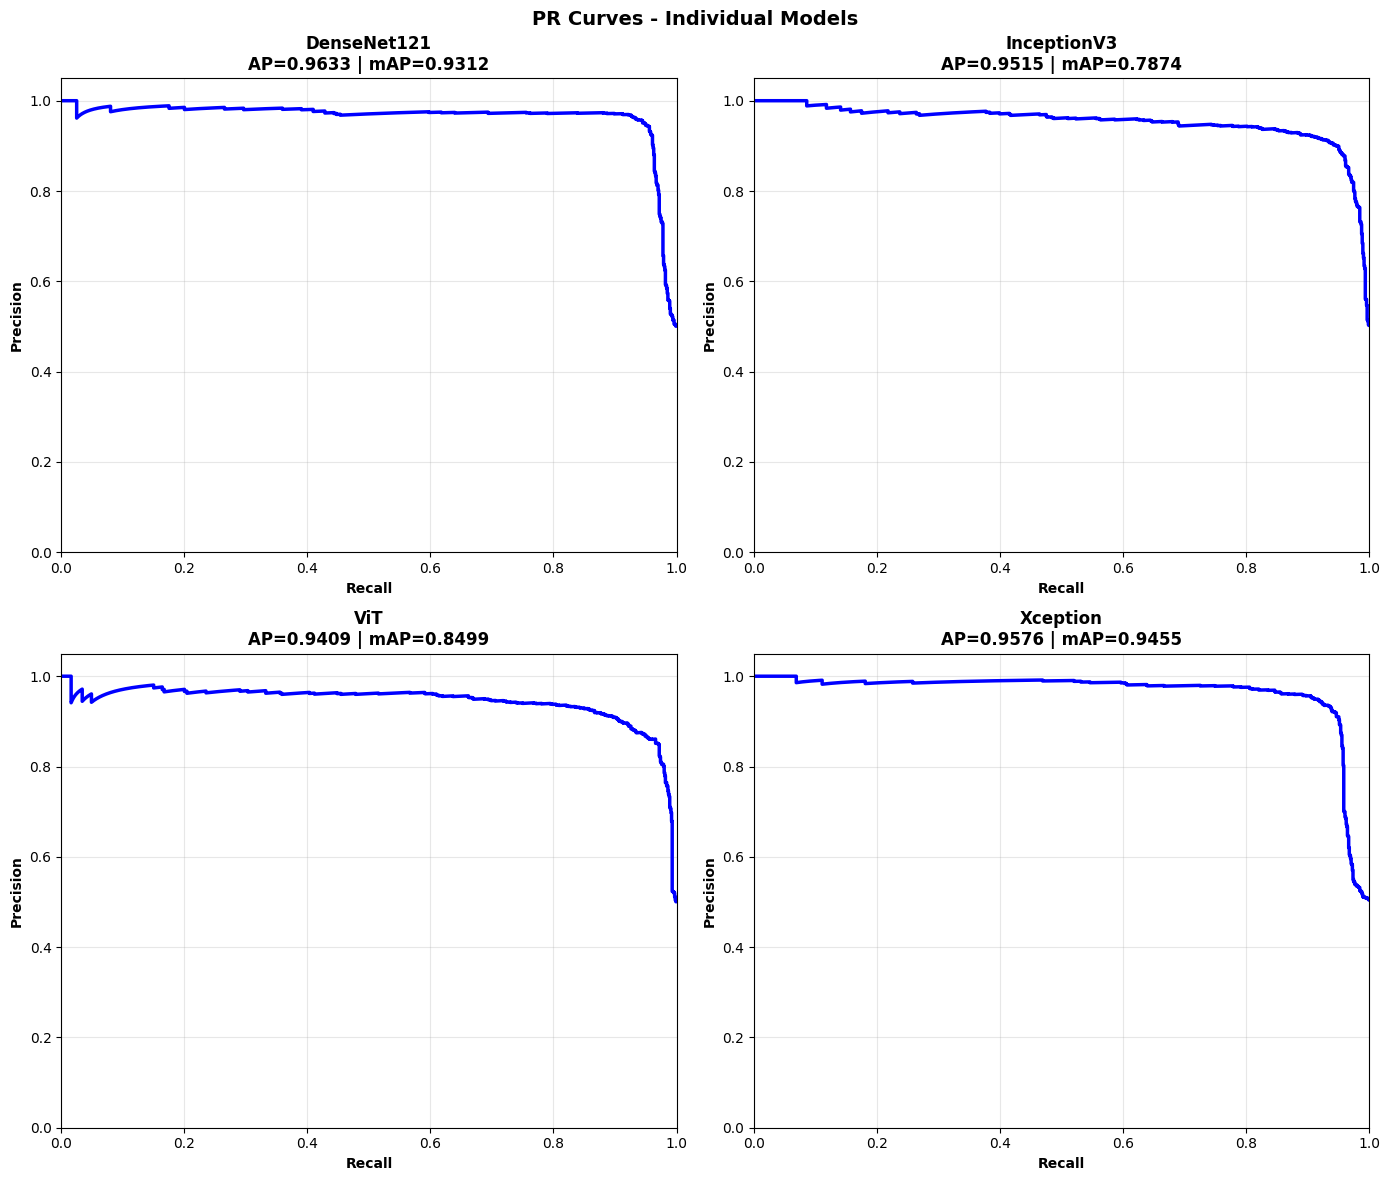

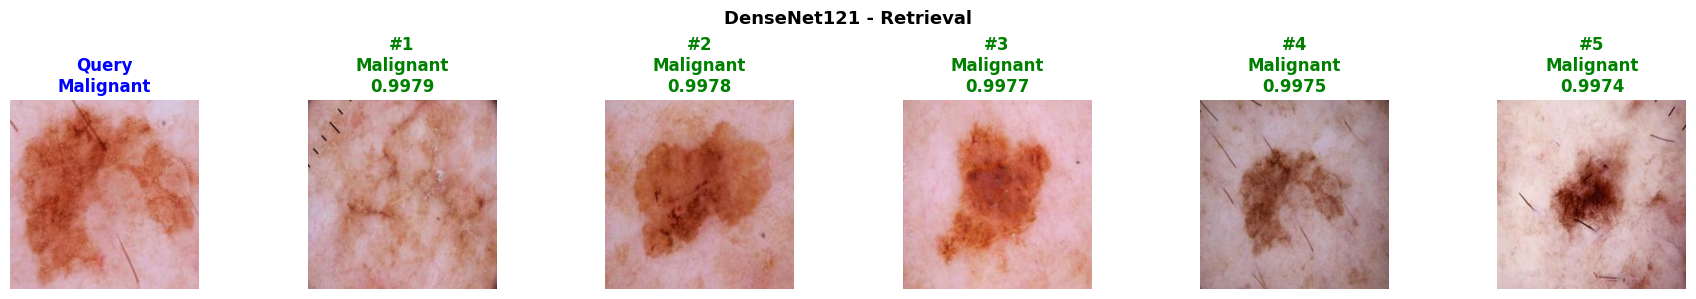

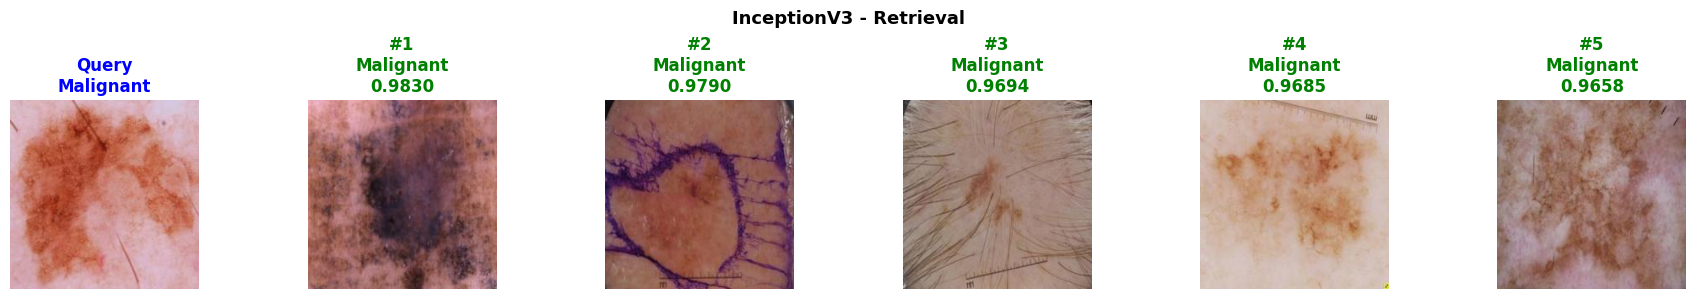

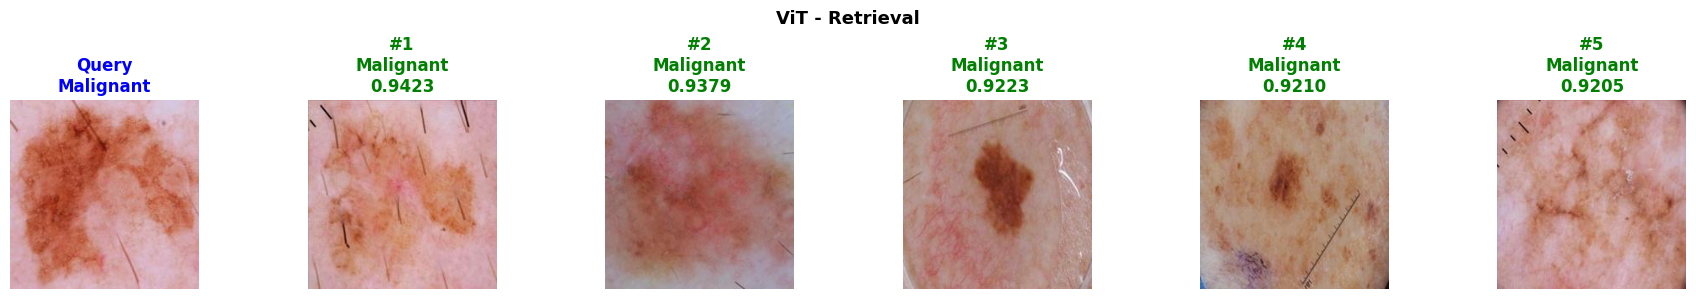

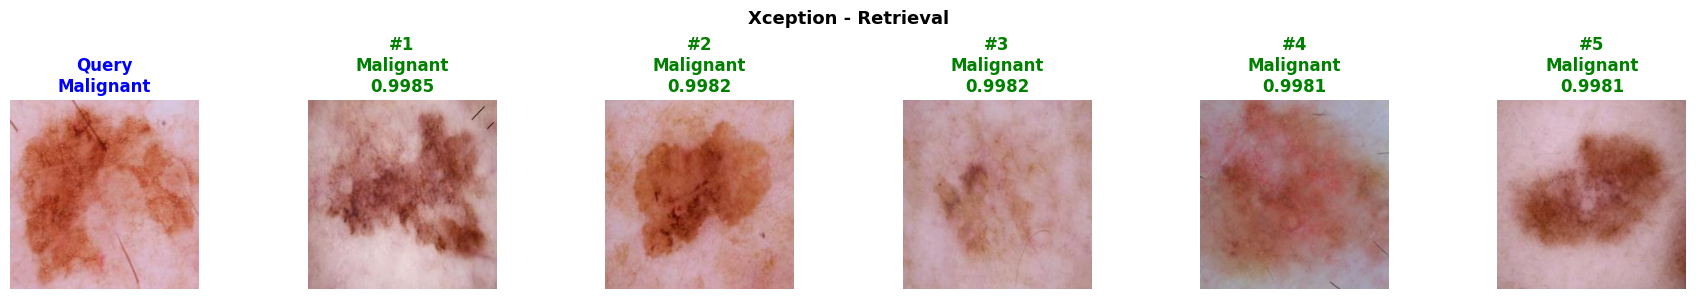


CBIR PERFORMANCE (20 Queries)
      Model    mAP
DenseNet121 0.9312
InceptionV3 0.7874
        ViT 0.8499
   Xception 0.9455
✓ Visualizations 9-11 complete!


In [12]:
# ============================================================================
# VISUALIZATION 9-11: Individual CBIR Results
# VIZ 9: PR curves
# VIZ 10: Retrieved images
# VIZ 11: mAP table
# ============================================================================

# VIZ 9: PR curves for sample query
sample_q = queries_d[0]
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
for i, (name, feats, mAP, ap) in enumerate([
    ('DenseNet121', feats_d, mAP_d, aps_d[0]),
    ('InceptionV3', feats_i, mAP_i, aps_i[0]),
    ('ViT', feats_v, mAP_v, aps_v[0]),
    ('Xception', feats_x, mAP_x, aps_x[0])
]):
    sims = compute_similarity(feats[sample_q], feats)
    prec, rec = calc_pr_curve(test_labels[sample_q], test_labels, sims)
    ax.ravel()[i].plot(rec, prec, 'b-', lw=2.5)
    ax.ravel()[i].set_xlabel('Recall', fontweight='bold')
    ax.ravel()[i].set_ylabel('Precision', fontweight='bold')
    ax.ravel()[i].set_title(f'{name}\nAP={ap:.4f} | mAP={mAP:.4f}', fontweight='bold')
    ax.ravel()[i].grid(alpha=0.3); ax.ravel()[i].set_xlim([0,1]); ax.ravel()[i].set_ylim([0,1.05])
plt.suptitle('PR Curves - Individual Models', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('results/09_pr_curves_individual.png', dpi=300, bbox_inches='tight'); plt.show()

# VIZ 10: Retrieved images (function)
def viz_retrieval(q_idx, feats, labels, files, name, k=5):
    top_idx, top_sims, top_labels = retrieve_similar(q_idx, feats, labels, k)
    fig, ax = plt.subplots(1, k+1, figsize=(18, 3))
    
    # Query
    q_img = load_img(f"{TEST_PATH}/{files[q_idx]}", target_size=IMG_224)
    ax[0].imshow(q_img); ax[0].axis('off')
    ax[0].set_title(f'Query\n{CLASS_NAMES[labels[q_idx]]}', fontweight='bold', color='blue')
    
    # Retrieved
    for i, (idx, sim, lbl) in enumerate(zip(top_idx, top_sims, top_labels)):
        img = load_img(f"{TEST_PATH}/{files[idx]}", target_size=IMG_224)
        ax[i+1].imshow(img); ax[i+1].axis('off')
        color = 'green' if lbl == labels[q_idx] else 'red'
        ax[i+1].set_title(f'#{i+1}\n{CLASS_NAMES[lbl]}\n{sim:.4f}', fontweight='bold', color=color)
    
    plt.suptitle(f'{name} - Retrieval', fontweight='bold', fontsize=13)
    plt.tight_layout(); return fig

# Generate retrieval visualizations
for name, feats in [('DenseNet121', feats_d), ('InceptionV3', feats_i), ('ViT', feats_v), ('Xception', feats_x)]:
    fig = viz_retrieval(sample_q, feats, test_labels, test_files, name)
    plt.savefig(f'results/10_retrieval_{name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show(); plt.close()

# VIZ 11: mAP table
cbir_df = pd.DataFrame([{'Model': n, 'mAP': f"{cbir_results[n]['mAP']:.4f}"} for n in ['DenseNet121', 'InceptionV3', 'ViT', 'Xception']])
print("\n" + "="*50 + "\nCBIR PERFORMANCE (20 Queries)\n" + "="*50)
print(cbir_df.to_string(index=False))
print("="*50)
cbir_df.to_csv('results/11_cbir_individual.csv', index=False)
print("✓ Visualizations 9-11 complete!")

In [13]:
# ============================================================================
# SECTION 23: FEATURE-LEVEL FUSION (Multi-Model CBIR)
# ============================================================================

# Normalize features
feats_d_n = normalize(feats_d, axis=1)
feats_i_n = normalize(feats_i, axis=1)
feats_v_n = normalize(feats_v, axis=1)
feats_x_n = normalize(feats_x, axis=1)

# Use ensemble weights for fusion
fusion_w = opt_w.copy()

# Weighted concatenation
feats_fused = np.concatenate([
    feats_d_n * fusion_w['DenseNet121'],
    feats_i_n * fusion_w['InceptionV3'],
    feats_v_n * fusion_w['ViT'],
    feats_x_n * fusion_w['Xception']
], axis=1)

print(f"Fused features shape: {feats_fused.shape}")
np.save('features/fused.npy', feats_fused)

# Evaluate fused CBIR
mAP_fused, queries_fused, aps_fused = evaluate_cbir(feats_fused, test_labels, 20)
print(f"\nMulti-Model Fusion mAP: {mAP_fused:.4f}")
print(f"Improvement: +{(mAP_fused - max(mAP_d, mAP_i, mAP_v, mAP_x)):.4f}")
print("✓ Feature fusion complete!")

Fused features shape: (2000, 3584)

Multi-Model Fusion mAP: 0.9730
Improvement: +0.0274
✓ Feature fusion complete!


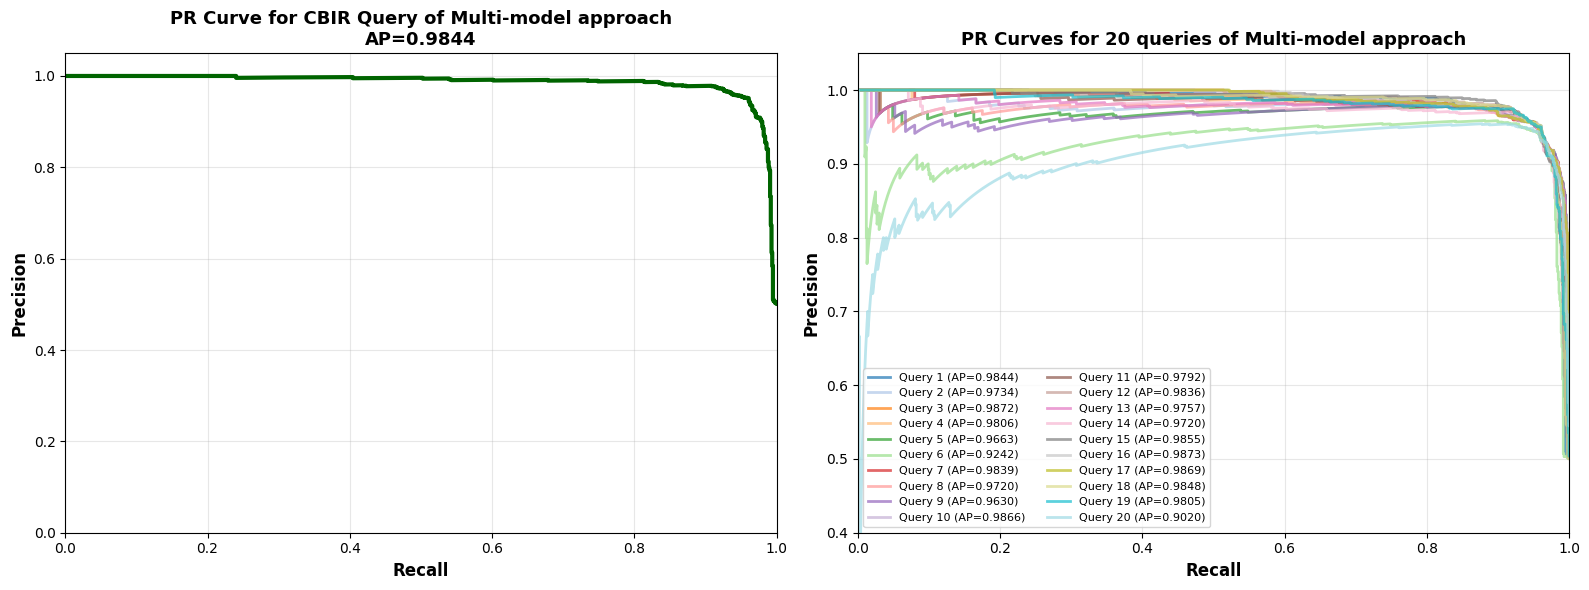


Multi-Model Fusion CBIR Results:
  Sample Query AP: 0.9844
  Mean AP (20 queries): 0.9730
  Min AP: 0.9020
  Max AP: 0.9873


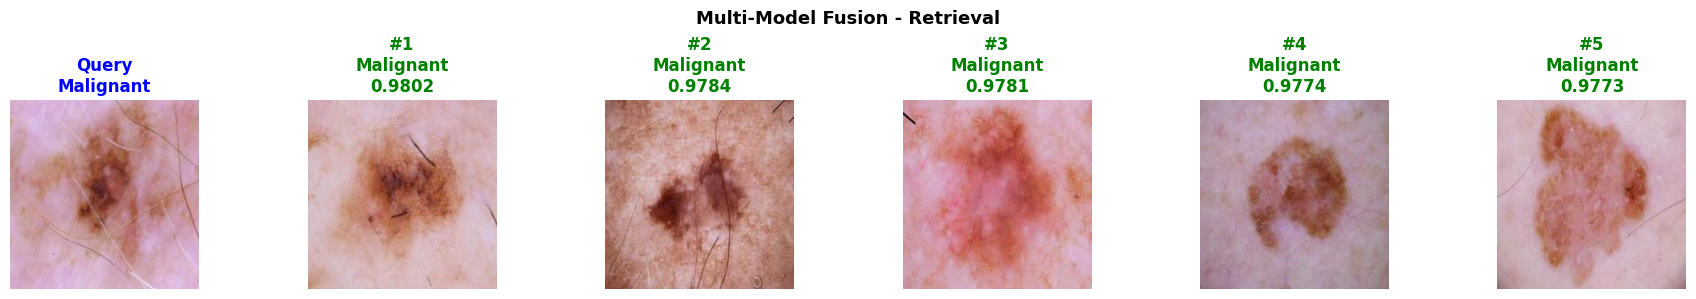


COMPLETE CBIR COMPARISON
             Model    mAP
       DenseNet121 0.9312
       InceptionV3 0.7874
               ViT 0.8499
          Xception 0.9455
Multi-Model Fusion 0.9730
✓ Visualizations 12-14 complete!


In [14]:
# ============================================================================
# VISUALIZATION 12-14: Multi-Model CBIR Results
# VIZ 12: PR curves (Single query + All 20 queries)
# VIZ 13: Retrieved images
# VIZ 14: mAP table
# ============================================================================

# VIZ 12: PR curves - TWO SUBPLOTS like in paper
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Single query PR curve
sample_q_fused = queries_fused[0]
sims_fused = compute_similarity(feats_fused[sample_q_fused], feats_fused)
prec_fused, rec_fused = calc_pr_curve(test_labels[sample_q_fused], test_labels, sims_fused)

axes[0].plot(rec_fused, prec_fused, 'darkgreen', lw=3)
axes[0].set_xlabel('Recall', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Precision', fontweight='bold', fontsize=12)
axes[0].set_title(f'PR Curve for CBIR Query of Multi-model approach\nAP={aps_fused[0]:.4f}', 
                  fontweight='bold', fontsize=13)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# RIGHT: All 20 queries PR curves
colors = plt.cm.tab20(np.linspace(0, 1, 20))
for i, q_idx in enumerate(queries_fused):
    sims = compute_similarity(feats_fused[q_idx], feats_fused)
    prec, rec = calc_pr_curve(test_labels[q_idx], test_labels, sims)
    axes[1].plot(rec, prec, lw=2, color=colors[i], alpha=0.7,
                label=f'Query {i+1} (AP={aps_fused[i]:.4f})')

axes[1].set_xlabel('Recall', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Precision', fontweight='bold', fontsize=12)
axes[1].set_title('PR Curves for 20 queries of Multi-model approach', 
                  fontweight='bold', fontsize=13)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0.4, 1.05])  # Match paper's y-axis range
axes[1].legend(loc='lower left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('results/12_pr_curves_fusion_all.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMulti-Model Fusion CBIR Results:")
print(f"  Sample Query AP: {aps_fused[0]:.4f}")
print(f"  Mean AP (20 queries): {mAP_fused:.4f}")
print(f"  Min AP: {min(aps_fused):.4f}")
print(f"  Max AP: {max(aps_fused):.4f}")

# VIZ 13: Retrieved images
fig = viz_retrieval(sample_q_fused, feats_fused, test_labels, test_files, 'Multi-Model Fusion')
plt.savefig('results/13_retrieval_fusion.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# VIZ 14: mAP table
fusion_df = pd.DataFrame([{'Model': 'Multi-Model Fusion', 'mAP': f"{mAP_fused:.4f}"}])
all_cbir_df = pd.concat([cbir_df, fusion_df], ignore_index=True)
print("\n" + "="*50 + "\nCOMPLETE CBIR COMPARISON\n" + "="*50)
print(all_cbir_df.to_string(index=False))
print("="*50)
all_cbir_df.to_csv('results/14_cbir_all.csv', index=False)
print("✓ Visualizations 12-14 complete!")

In [15]:
# ============================================================================
# SECTION 26-27: BOOTSTRAP CONFIDENCE INTERVALS
# VISUALIZATION 15-16: CI Tables
# ============================================================================

def bootstrap_ci(data, n=100):
    scores = [np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(n)]
    mean, std = np.mean(data), np.std(scores)
    ci_w = 1.96 * std / np.sqrt(n)
    return mean, std, ci_w, (mean - ci_w, mean + ci_w)

# VIZ 15: Accuracy CI
acc_ci_results = []
for name, result in [('DenseNet121', res_d), ('InceptionV3', res_i), ('ViT', res_v), ('Xception', res_x), ('Ensemble', res_ens)]:
    y_t, y_p = result['y_true'], result['y_pred']
    accs = [accuracy_score(y_t[np.random.choice(len(y_t), len(y_t), replace=True)],
                          y_p[np.random.choice(len(y_p), len(y_p), replace=True)]) for _ in range(100)]
    mean, std, ci_w, ci_r = bootstrap_ci(np.array(accs))
    acc_ci_results.append({
        'Model': name, 'Accuracy': f"{mean*100:.2f}%", 'Std': f"{std*100:.2f}%",
        'CI Width': f"±{ci_w*100:.3f}", '95% CI': f"({ci_r[0]*100:.2f}–{ci_r[1]*100:.2f})"
    })

acc_ci_df = pd.DataFrame(acc_ci_results)
print("\n" + "="*100 + "\nACCURACY - 95% CI (Bootstrap n=100)\n" + "="*100)
print(acc_ci_df.to_string(index=False))
print("="*100)
acc_ci_df.to_csv('results/15_accuracy_ci.csv', index=False)

# VIZ 16: mAP CI
mAP_ci_results = []
for name, aps in [('DenseNet121', aps_d), ('InceptionV3', aps_i), ('ViT', aps_v), ('Xception', aps_x), ('Multi-Model Fusion', aps_fused)]:
    mean, std, ci_w, ci_r = bootstrap_ci(np.array(aps))
    mAP_ci_results.append({
        'Model': name, 'mAP': f"{mean:.4f}", 'Std': f"{std:.4f}",
        'CI Width': f"±{ci_w:.6f}", '95% CI': f"({ci_r[0]:.4f}–{ci_r[1]:.4f})"
    })

mAP_ci_df = pd.DataFrame(mAP_ci_results)
print("\n" + "="*100 + "\nmAP - 95% CI (Bootstrap n=100)\n" + "="*100)
print(mAP_ci_df.to_string(index=False))
print("="*100)
mAP_ci_df.to_csv('results/16_mAP_ci.csv', index=False)
print("✓ Visualizations 15-16 complete!")


ACCURACY - 95% CI (Bootstrap n=100)
      Model Accuracy   Std CI Width        95% CI
DenseNet121   50.11% 0.12%   ±0.024 (50.08–50.13)
InceptionV3   50.23% 0.09%   ±0.019 (50.21–50.25)
        ViT   50.09% 0.09%   ±0.018 (50.07–50.10)
   Xception   50.03% 0.09%   ±0.018 (50.01–50.05)
   Ensemble   49.86% 0.12%   ±0.024 (49.84–49.88)

mAP - 95% CI (Bootstrap n=100)
             Model    mAP    Std  CI Width          95% CI
       DenseNet121 0.9312 0.0346 ±0.006774 (0.9244–0.9379)
       InceptionV3 0.7874 0.0551 ±0.010797 (0.7766–0.7982)
               ViT 0.8499 0.0466 ±0.009142 (0.8407–0.8590)
          Xception 0.9455 0.0066 ±0.001297 (0.9442–0.9468)
Multi-Model Fusion 0.9730 0.0049 ±0.000957 (0.9720–0.9739)
✓ Visualizations 15-16 complete!



FINAL COMPREHENSIVE SUMMARY

1. CLASSIFICATION PERFORMANCE:
----------------------------------------------------------------------------------------------------
      Model accuracy precision recall f1_score
DenseNet121   94.60%    95.88% 93.20%   94.52%
InceptionV3   92.00%    94.40% 89.30%   91.78%
        ViT   89.70%    94.11% 84.70%   89.16%
   Xception   93.15%    95.18% 90.90%   92.99%

   Model accuracy precision recall f1_score
Ensemble   95.30%    96.51% 94.00%   95.24%


2. CBIR PERFORMANCE (mAP for 20 Queries):
----------------------------------------------------------------------------------------------------
             Model    mAP
       DenseNet121 0.9312
       InceptionV3 0.7874
               ViT 0.8499
          Xception 0.9455
Multi-Model Fusion 0.9730


3. ENSEMBLE WEIGHTS:
----------------------------------------------------------------------------------------------------
DenseNet121         : 0.526368
InceptionV3         : 0.094635
ViT                 : 0.189

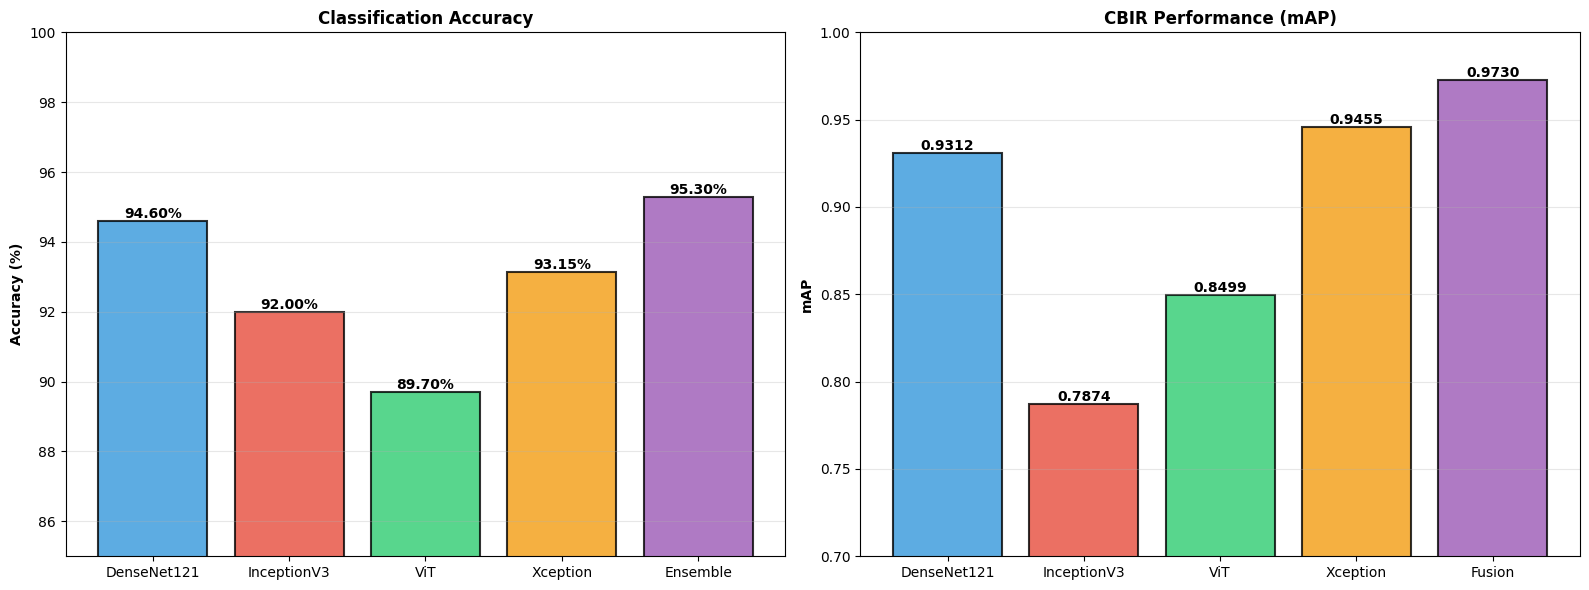

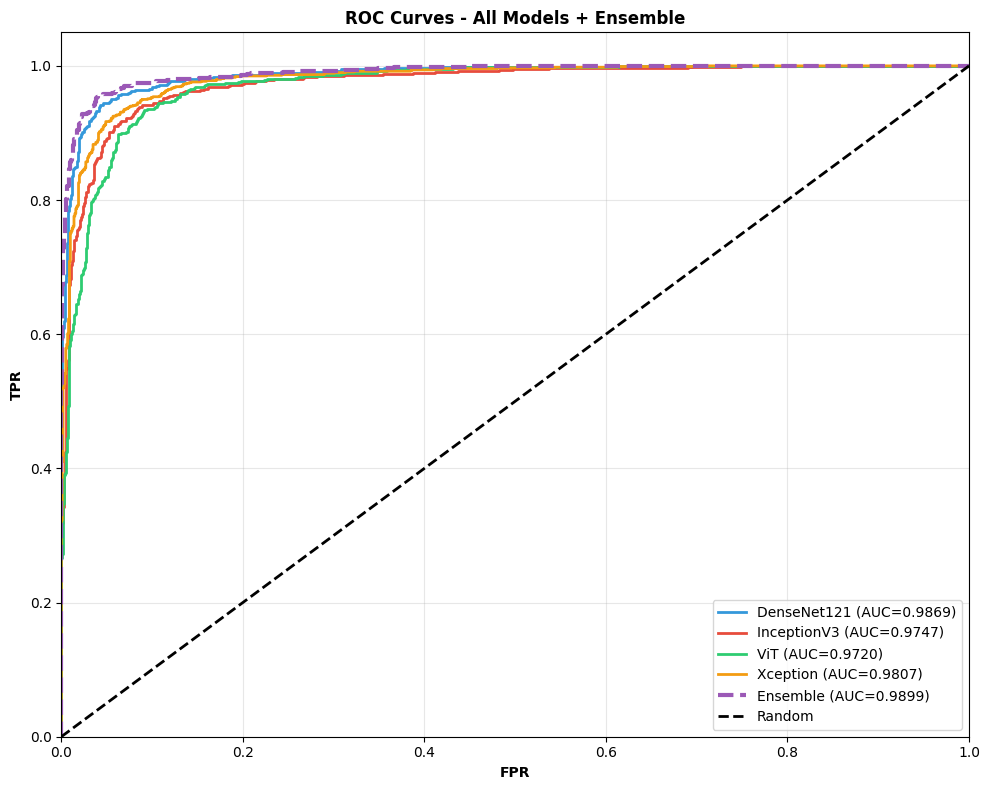

In [16]:
# ============================================================================
# SECTION 28-30: FINAL SUMMARY & ADDITIONAL VISUALIZATIONS
# ============================================================================

# Summary
print("\n" + "="*100)
print("FINAL COMPREHENSIVE SUMMARY")
print("="*100)

print("\n1. CLASSIFICATION PERFORMANCE:")
print("-" * 100)
print(perf_df.to_string(index=False))
print("\n" + ens_perf_df.to_string(index=False))

print("\n\n2. CBIR PERFORMANCE (mAP for 20 Queries):")
print("-" * 100)
print(all_cbir_df.to_string(index=False))

print("\n\n3. ENSEMBLE WEIGHTS:")
print("-" * 100)
for n, w in opt_w.items(): print(f"{n:20s}: {w:.6f}")

print("\n\n4. KEY ACHIEVEMENTS:")
print("-" * 100)
print(f"✓ Best Individual Accuracy: {max([r['accuracy'] for r in all_results])*100:.2f}% (DenseNet121)")
print(f"✓ Ensemble Accuracy: {ens_acc*100:.2f}%")
print(f"✓ Improvement: +{(ens_acc - max([r['accuracy'] for r in all_results]))*100:.2f}%")
print(f"✓ Best Individual mAP: {max(mAP_d, mAP_i, mAP_v, mAP_x):.4f} (DenseNet121)")
print(f"✓ Multi-Model Fusion mAP: {mAP_fused:.4f}")
print(f"✓ Improvement: +{(mAP_fused - max(mAP_d, mAP_i, mAP_v, mAP_x)):.4f}")

print("\n" + "="*100)
print("REPLICATION COMPLETE!")
print("="*100)

# Bar charts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
models = ['DenseNet121', 'InceptionV3', 'ViT', 'Xception', 'Ensemble']
accs = [res_d['accuracy']*100, res_i['accuracy']*100, res_v['accuracy']*100, res_x['accuracy']*100, ens_acc*100]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

bars1 = ax[0].bar(models, accs, color=colors, alpha=0.8, edgecolor='black', lw=1.5)
ax[0].set_ylabel('Accuracy (%)', fontweight='bold'); ax[0].set_title('Classification Accuracy', fontweight='bold')
ax[0].set_ylim([85, 100]); ax[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    h = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}%', ha='center', va='bottom', fontweight='bold')

mAPs_all = [mAP_d, mAP_i, mAP_v, mAP_x, mAP_fused]
models2 = models[:-1] + ['Fusion']
bars2 = ax[1].bar(models2, mAPs_all, color=colors, alpha=0.8, edgecolor='black', lw=1.5)
ax[1].set_ylabel('mAP', fontweight='bold'); ax[1].set_title('CBIR Performance (mAP)', fontweight='bold')
ax[1].set_ylim([0.7, 1.0]); ax[1].grid(axis='y', alpha=0.3)
for bar in bars2:
    h = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, h, f'{h:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout(); plt.savefig('results/comparison_bars.png', dpi=300, bbox_inches='tight'); plt.show()

# Combined ROC
plt.figure(figsize=(10, 8))
for r, c, n in [(res_d, '#3498db', 'DenseNet121'), (res_i, '#e74c3c', 'InceptionV3'),
                (res_v, '#2ecc71', 'ViT'), (res_x, '#f39c12', 'Xception')]:
    plt.plot(r['fpr'], r['tpr'], color=c, lw=2, label=f"{n} (AUC={r['auc']:.4f})")
plt.plot(fpr_e, tpr_e, '#9b59b6', lw=3, linestyle='--', label=f"Ensemble (AUC={ens_auc:.4f})")
plt.plot([0,1], [0,1], 'k--', lw=2, label='Random')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('FPR', fontweight='bold'); plt.ylabel('TPR', fontweight='bold')
plt.title('ROC Curves - All Models + Ensemble', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('results/roc_complete.png', dpi=300, bbox_inches='tight'); plt.show()

# Save summary
with open('results/COMPLETE_SUMMARY.txt', 'w') as f:
    f.write("="*100 + "\n")
    f.write("MELANOMA CLASSIFICATION & CBIR - COMPLETE RESULTS\n")
    f.write("="*100 + "\n\n")
    f.write(f"Dataset: {sum(img_counts['train'].values())} train, {sum(img_counts['test'].values())} test\n\n")
    f.write("1. CLASSIFICATION\n" + "-"*100 + "\n")
    f.write(perf_df.to_string(index=False) + "\n\n" + ens_perf_df.to_string(index=False) + "\n\n")
    f.write("2. CBIR\n" + "-"*100 + "\n" + all_cbir_df.to_string(index=False) + "\n\n")
    f.write("3. CONFIDENCE INTERVALS\n" + "-"*100 + "\n")
    f.write("Accuracy:\n" + acc_ci_df.to_string(index=False) + "\n\n")
    f.write("mAP:\n" + mAP_ci_df.to_string(index=False) + "\n\n")
    f.write("="*100 + "\n")